### 1. Liiketoiminnan ymmärrys

#### Tavoite
- Tutkia miten uni- ja liikuntatottumukset vaikuttavat hyvinvointiin ja aktiivisuustasoon.

#### Keskeiset kysymykset
- Onko eri käyttäjäryhmillä selkeitä eroja unirytmissä ja liikuntamäärissä?
- Mitkä tekijät vaikuttavat unen määrään ja tasoon?

#### Vaadittava data
- Uni (kesto, taso)
- Liikunta (päivittäiset askeleet, aktiivisuusminuutit, kulutetut kalorit)
- Mahdollisesti lisämuuttujat (syke ja paino)

#### Mahdolliset rajoitteet
- Datan puute (Unen tasot puuttuvat, joten joudumme käyttämään epäsuoria mittareita kuten sykettä, liikunnan vaikutusta uneen, unen kestoa ja sen säännöllisyyttä.
- Käyttäjien erilaiset elämäntyylit ja taustatekijät
- Älykellodatan mahdollinen epätarkkuus

#### Odotetut tulokset
- Käyttäjäryhmien (klusterien) löytäminen unen laadun ja aktiivisuustottumusten perusteella
- Ennustemalli, joka arvioi aktiivisuustason unen perusteella
- Oletuksena se, että liikunnan määrä ja kulutetut kalorit vaikuttaisivat positiivisesti unen määrään ja laatuun


### 2. Datan ymmärtäminen: Toinen vaihe on kerätä ja tutkia dataa. Mitä dataa on saatavilla? Mitkä ovat datan ominaisuudet (muuttujien tyypit, arvojen jakaumat jne.)? Onko datassa laatuongelmia (puuttuvat arvot, poikkeamat, järjettömät arvot)?

#### Tietoa datasetistä

"Tämä aineisto on kerätty vastaajilta hajautetun kyselyn kautta Amazon Mechanical Turkin avulla ajanjaksolla 03.12.2016–05.12.2016. Kolmekymmentä kelpoisuusehdot täyttävää Fitbit-käyttäjää antoi suostumuksensa henkilökohtaisten aktiivisuusmittaridatojen lähettämiseen, mukaan lukien minuuttitasoiset tiedot fyysisestä aktiivisuudesta, sykkeestä ja unen seurannasta. Eri laitteiden ja käyttäjien yksilölliset seurantatavat ja mieltymykset aiheuttavat vaihtelua aineiston tuloksissa."


Lähde: https://www.kaggle.com/datasets/nurudeenabdulsalaam/fitbit-fitness-tracker-data/data

#### Yleiset muuttujat
1. Id: Käyttäjän yksilöivä tunniste
2. TotalSteps: Päivän aikana otetut askeleet
3. TotalDistance: Kuljettu matka kilometreissä
4. Calories: Arvio kulutetuista kaloreista
5. Sleep.Value: 1 = Sleep / 2 = restless / 3 = Awake

In [125]:
from operator import index

import correlation
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.constants import minute

dailyData = pd.read_csv('archive/merged_daily_activity.csv')
weight_data = pd.read_csv('archive/weightLogInfo_merged.csv')


### Havaintoja aktiivisuuteen ja uneen liittyvästä datasta
1. 0 arvoisia minimi arvoja. Eli voi olettaa että käyttäjät eivät ole käyttänneet laitettaan.
2. Tyhjiä arvoja joissakin sarakkeissa. Nämä poistetaan.
3. Epäloogista dataa, kuten negatiivisa arvoja ei ole.
4. Data on muuten valmiiksi käsiteltävissä, paitsi ActivityDate ja Date ovat objekteja. Ne täytyy muuttaa datetime muotoon.

In [126]:
dailyData.describe()

,Id,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,...,TotalSleepRecords,TotalMinutesAsleep,TotalTimeInBed,SleepLevel_1,SleepLevel_2,SleepLevel_3,avg_heart_rate,sum_heart_rate,max_heart_rate,min_heart_rate
count,9.400000e+02,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000,...,410.000000,410.000000,410.000000,410.000000,410.000000,410.000000,334.000000,3.340000e+02,334.000000,334.000000
mean,4.855407e+09,7637.910638,5.489702,5.475351,0.108171,1.502681,0.567543,3.340819,0.001606,21.164894,...,1.126829,422.536585,461.995122,0.926034,0.072049,0.009234,78.614059,5.750220e+05,138.703593,52.691617
std,2.424805e+09,5087.150742,3.924606,3.907276,0.619897,2.658941,0.883580,2.040655,0.007346,32.844803,...,0.354520,126.298633,134.719431,0.121532,0.084275,0.011872,10.613254,3.633880e+05,21.687215,7.427171
min,1.503960e+09,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,58.000000,61.000000,0.459215,0.000000,0.000000,59.377175,1.554000e+03,80.000000,36.000000
25%,2.320127e+09,3789.750000,2.620000,2.620000,0.000000,0.000000,0.000000,1.945000,0.000000,0.000000,...,1.000000,361.000000,406.000000,0.915144,0.033055,0.001847,70.465679,4.355502e+05,125.000000,48.000000
50%,4.445115e+09,7405.500000,5.245000,5.245000,0.000000,0.210000,0.240000,3.365000,0.000000,4.000000,...,1.000000,433.000000,463.500000,0.943671,0.049698,0.006401,77.494179,5.522510e+05,135.500000,52.000000
75%,6.962181e+09,10727.000000,7.712500,7.710000,0.000000,2.052500,0.800000,4.782500,0.000000,32.000000,...,1.000000,492.000000,529.250000,0.962159,0.071429,0.011818,84.933171,6.655475e+05,153.000000,56.000000
max,8.877689e+09,36019.000000,28.030001,28.030001,4.942142,21.920000,6.480000,10.710000,0.110000,210.000000,...,3.000000,1040.000000,1086.000000,1.925170,0.519637,0.105973,109.789625,3.117672e+06,203.000000,71.000000


In [127]:
dailyData.dtypes

Id                            int64
ActivityDate                 object
TotalSteps                    int64
TotalDistance               float64
TrackerDistance             float64
LoggedActivitiesDistance    float64
VeryActiveDistance          float64
ModeratelyActiveDistance    float64
LightActiveDistance         float64
SedentaryActiveDistance     float64
VeryActiveMinutes             int64
FairlyActiveMinutes           int64
LightlyActiveMinutes          int64
SedentaryMinutes              int64
Calories                      int64
TotalSleepRecords           float64
TotalMinutesAsleep          float64
TotalTimeInBed              float64
SleepLevel_1                float64
SleepLevel_2                float64
SleepLevel_3                float64
avg_heart_rate              float64
sum_heart_rate              float64
max_heart_rate              float64
min_heart_rate              float64
dtype: object

In [128]:
print(dailyData.isnull().sum())

Id                            0
ActivityDate                  0
TotalSteps                    0
TotalDistance                 0
TrackerDistance               0
LoggedActivitiesDistance      0
VeryActiveDistance            0
ModeratelyActiveDistance      0
LightActiveDistance           0
SedentaryActiveDistance       0
VeryActiveMinutes             0
FairlyActiveMinutes           0
LightlyActiveMinutes          0
SedentaryMinutes              0
Calories                      0
TotalSleepRecords           530
TotalMinutesAsleep          530
TotalTimeInBed              530
SleepLevel_1                530
SleepLevel_2                530
SleepLevel_3                530
avg_heart_rate              606
sum_heart_rate              606
max_heart_rate              606
min_heart_rate              606
dtype: int64


In [129]:
weight_data.dtypes

Id                  int64
Date               object
WeightKg          float64
WeightPounds      float64
Fat               float64
BMI               float64
IsManualReport       bool
LogId               int64
dtype: object

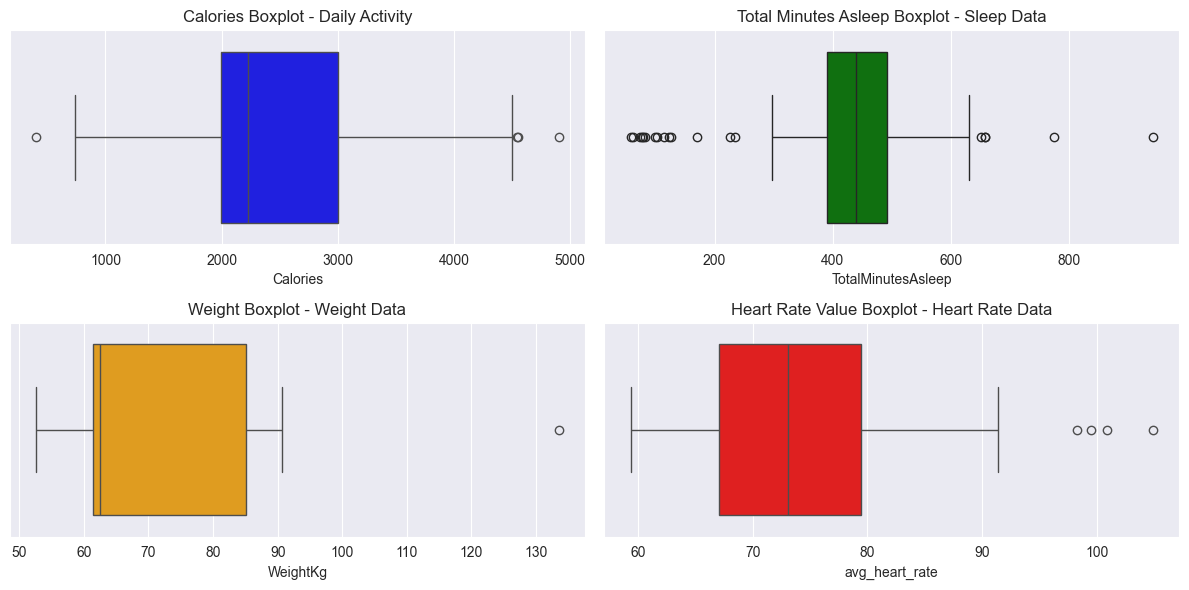

In [130]:

# Drop NaN values to avoid issues
dailyData = dailyData.dropna(subset=['Calories', 'TotalMinutesAsleep', 'avg_heart_rate'])
weight_data = weight_data.dropna(subset=['WeightKg'])

# Ensure numeric data type
dailyData['TotalMinutesAsleep'] = pd.to_numeric(dailyData['TotalMinutesAsleep'], errors='coerce')

plt.figure(figsize=(12, 6))

# Boxplot for Daily Activity Calories
plt.subplot(2, 2, 1)
sns.boxplot(x=dailyData['Calories'], color='blue')
plt.title('Calories Boxplot - Daily Activity')

# Boxplot for Sleep TotalMinutesAsleep
plt.subplot(2, 2, 2)
sns.boxplot(x=dailyData['TotalMinutesAsleep'], color='green')
plt.title('Total Minutes Asleep Boxplot - Sleep Data')

# Boxplot for Weight
plt.subplot(2, 2, 3)
sns.boxplot(x=weight_data['WeightKg'], color='orange')
plt.title('Weight Boxplot - Weight Data')

# Boxplot for Heart Rate Value
plt.subplot(2, 2, 4)
sns.boxplot(x=dailyData['avg_heart_rate'], color='red')
plt.title('Heart Rate Value Boxplot - Heart Rate Data')

plt.tight_layout()
plt.show()


In [131]:

print("Check for Negative Values in Sleep Data:")
print(dailyData[dailyData['TotalMinutesAsleep'] < 0], '\n')

Check for Negative Values in Sleep Data:
Empty DataFrame
Columns: [Id, ActivityDate, TotalSteps, TotalDistance, TrackerDistance, LoggedActivitiesDistance, VeryActiveDistance, ModeratelyActiveDistance, LightActiveDistance, SedentaryActiveDistance, VeryActiveMinutes, FairlyActiveMinutes, LightlyActiveMinutes, SedentaryMinutes, Calories, TotalSleepRecords, TotalMinutesAsleep, TotalTimeInBed, SleepLevel_1, SleepLevel_2, SleepLevel_3, avg_heart_rate, sum_heart_rate, max_heart_rate, min_heart_rate]
Index: []

[0 rows x 25 columns] 



In [132]:

print("Check for Negative or Unrealistic Weight in Weight Data:")
print(weight_data[weight_data['WeightKg'] < 0], '\n')

Check for Negative or Unrealistic Weight in Weight Data:
Empty DataFrame
Columns: [Id, Date, WeightKg, WeightPounds, Fat, BMI, IsManualReport, LogId]
Index: [] 



### 3. Datan valmistelu: Kolmas vaihe on esikäsitellä data. Tämä sisältää datan puhdistamisen, muuntamisen ja olennaisten ominaisuuksien valitsemisen. Nämä vaiheet tulisi dokumentoida niin yksityiskohtaisesti, että ne voidaan toistaa myöhemmin.


In [133]:
dailyData['ActivityDate'] = pd.to_datetime(dailyData['ActivityDate'], format='%Y-%m-%d', errors='coerce')
weight_data['Date'] = pd.to_datetime(weight_data['Date'], format='%Y-%m-%d', errors='coerce')


# Recalculate PoorSleep based on the SleepLevel percentages
# PoorSleep = (Restless Sleep + Awake Sleep)
dailyData['PoorSleep'] = dailyData['SleepLevel_2'] + dailyData['SleepLevel_3']

# Aggregate daily sleep data by Id (average TotalMinutesAsleep, TotalTimeInBed, PoorSleep)
agg_sleep_data = dailyData.groupby('Id').agg(
    AvgTotalMinutesAsleep=('TotalMinutesAsleep', 'mean'),
    AvgTotalTimeInBed=('TotalTimeInBed', 'mean'),
    AvgPoorSleep=('PoorSleep', 'mean')
).reset_index()

# Merge the aggregated sleep data with the weight data
merged_data = pd.merge(agg_sleep_data, weight_data[['Id', 'WeightKg']], on='Id')

# Perform correlation analysis
correlation_matrix = merged_data[['WeightKg', 'AvgTotalMinutesAsleep', 'AvgTotalTimeInBed', 'AvgPoorSleep']].corr()

# Output the correlation matrix
print("Correlation Matrix:")
print(correlation_matrix)
print('--------------------')

Correlation Matrix:
                       WeightKg  AvgTotalMinutesAsleep  AvgTotalTimeInBed  \
WeightKg               1.000000              -0.479072          -0.465287   
AvgTotalMinutesAsleep -0.479072               1.000000           0.999877   
AvgTotalTimeInBed     -0.465287               0.999877           1.000000   
AvgPoorSleep           0.635984              -0.981928          -0.978838   

                       AvgPoorSleep  
WeightKg                   0.635984  
AvgTotalMinutesAsleep     -0.981928  
AvgTotalTimeInBed         -0.978838  
AvgPoorSleep               1.000000  
--------------------
Correlation between Weight and Poor Sleep: 0.6359842910745673, p-value: 3.0657825793167674e-05


In [134]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Muutetaan päivämäärä oikeaan muotoon
dailyData["ActivityDate"] = pd.to_datetime(dailyData["ActivityDate"], format="%Y-%m-%d", errors='coerce')

# Poistetaan rivit, joissa uni- tai aktiivisuustiedot puuttuvat
dailyData.replace("<null>", pd.NA, inplace=True)  # Muutetaan <null> arvoiksi NaN
dailyData = dailyData.dropna(subset=["TotalMinutesAsleep"])

# Valitaan tarvittavat sarakkeet
df_selected = dailyData[["TotalSteps", "VeryActiveDistance", "VeryActiveMinutes",
                         "ModeratelyActiveDistance", "FairlyActiveMinutes",
                         "LightActiveDistance", "LightlyActiveMinutes", "SedentaryActiveDistance", "SedentaryMinutes", "TotalMinutesAsleep"]]

# Valitaan selittävät ja selitettävä muuttuja
X = df_selected[["TotalSteps", "VeryActiveDistance", "VeryActiveMinutes",
                 "ModeratelyActiveDistance", "FairlyActiveMinutes",
                 "LightActiveDistance", "LightlyActiveMinutes", "SedentaryActiveDistance", "SedentaryMinutes"]]
y = df_selected["TotalMinutesAsleep"]

# Standardoidaan muuttujat
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Sovitetaan lineaarinen regressiomalli
model = LinearRegression()
model.fit(X_scaled, y)

# Ennustetaan arvot ja lasketaan mallin selitysaste (R^2)
y_pred = model.predict(X_scaled)
r2 = r2_score(y, y_pred)

# Tallennetaan mallin kertoimet ja vakiotermi
coefs = model.coef_
intercept = model.intercept_

# Tulostetaan tulokset
print("Regressiokertoimet:")
for feature, coef in zip(["TotalSteps", "VeryActiveDistance", "VeryActiveMinutes",
                          "ModeratelyActiveDistance", "FairlyActiveMinutes",
                          "LightActiveDistance", "LightlyActiveMinutes", "SedentaryActiveDistance", "SedentaryMinutes"], coefs):
    print(f"{feature}: {coef:.2f}")

print("\n Y-Intercept:")
print(f"{intercept:.2f} (ilman liikuntaa unen keskiarvo olisi noin {intercept:.0f} minuuttia eli {intercept/60:.1f} tuntia)")

print("\n Selitysaste (R²):")
print(f"{r2:.3f} (malli selittää noin {r2*100:.1f} % unen vaihtelusta liikunnan perusteella)")


Regressiokertoimet:
TotalSteps: -3.59
VeryActiveDistance: 1.19
VeryActiveMinutes: -9.07
ModeratelyActiveDistance: 11.88
FairlyActiveMinutes: -20.81
LightActiveDistance: -4.56
LightlyActiveMinutes: -17.10
SedentaryActiveDistance: -4.29
SedentaryMinutes: -76.82

 Y-Intercept:
428.85 (ilman liikuntaa unen keskiarvo olisi noin 429 minuuttia eli 7.1 tuntia)

 Selitysaste (R²):
0.377 (malli selittää noin 37.7 % unen vaihtelusta liikunnan perusteella)


- TotalSteps (-3.59): Enemmän askeleita → lyhyempi uni. Aktiivisemmat ihmiset saattavat valvoa pidempään.
- VeryActiveDistance (1.19): Pitkä intensiivinen liikunta → hieman pidempi uni, parantaa palautumista.
- VeryActiveMinutes (-9.07): Paljon intensiivistä liikuntaa → lyhyempi uni, mahdollisesti stressin tai rasituksen vuoksi.
- ModeratelyActiveDistance (11.88): Kohtalainen liikunta → pidempi uni, tukee palautumista.
- ModeratelyActiveMinutes (-20.81): Kohtalainen aktiivisuus ilman pitkää matkaa → lyhyempi uni, voi liittyä unen laadun heikkenemiseen.
- LightActiveDistance (-4.56): Kevyt liikunta ei näytä parantavan unen määrää.
- LightlyActiveMinutes (-17.10): Pitkä kevyen aktiivisuuden kesto → unen väheneminen, voi häiritä palautumista.
- SedentaryMinutes (-4.29): Pitkä paikallaanolo → lyhyempi uni, mahdollisesti unirytmin häiriöistä johtuen.

### 4. Mallintaminen: Neljäs vaihe on valita koneoppimismenetelmä ja kouluttaa malli. Tämä vaihe sisältää myös mallin validoinnin. Dokumentaatioon tulee sisällyttää: mikä menetelmä valittiin, mitkä parametrit käytettiin, mikä oli mallin suorituskyky?


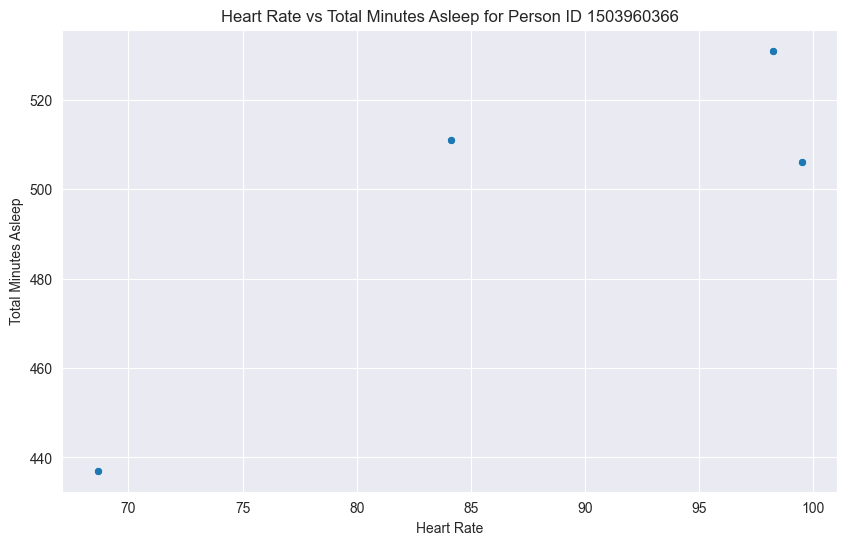

In [135]:
# Filter data for the specific person (Id = 1503960366)
person_data = dailyData[dailyData['Id'] == 2026352035]

# Scatter plot between heart rate and TotalMinutesAsleep for this person over the days
plt.figure(figsize=(10, 6))
sns.scatterplot(x=person_data['avg_heart_rate'], y=person_data['TotalMinutesAsleep'])
plt.title('Heart Rate vs Total Minutes Asleep for Person ID 1503960366')
plt.xlabel('Heart Rate')
plt.ylabel('Total Minutes Asleep')
plt.show()

Pearson correlation coefficient between SleepLevel_2 and VeryActiveMinutes: 0.00


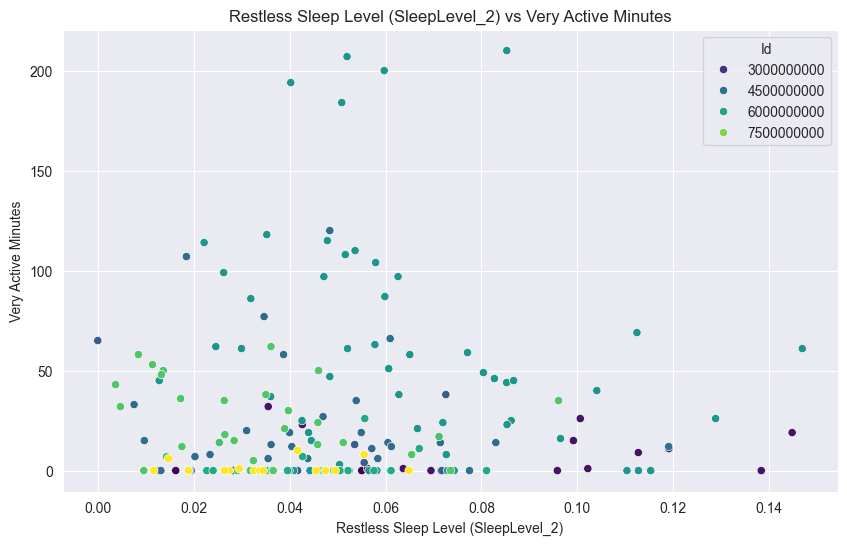

In [136]:

from scipy.stats import pearsonr

# Compute the Pearson correlation coefficient
correlation, p_value = pearsonr(dailyData['SleepLevel_2'], dailyData['VeryActiveMinutes'])

# Print the correlation coefficient
print(f"Pearson correlation coefficient between SleepLevel_2 and VeryActiveMinutes: {correlation:.2f}")

# Optionally, visualize the relationship with a scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x=dailyData['SleepLevel_2'], y=dailyData['VeryActiveMinutes'], hue=dailyData['Id'], palette='viridis')

# Add title and labels
plt.title('Restless Sleep Level (SleepLevel_2) vs Very Active Minutes')
plt.xlabel('Restless Sleep Level (SleepLevel_2)')
plt.ylabel('Very Active Minutes')

# Show the plot
plt.show()


### Pearson korrelaatio näyttää ylhäällä, että aktiivinen liikunta ja levoton uni eivät ole vahvasti korreloituneet keskenään. Tämä voi viitata siihen, että vaikka henkilö olisi levoton unen aikana, se ei välttämättä vaikuta hänen aktiivisuuteensa seuraavana päivänä.Toisaalta Aktiivinen liikunta  näyttäisi olevan korreloitunut paremmin hyvän unen kanssa.


                                Id  ActivityDate  TotalSteps  TotalDistance  \
Id                        1.000000     -0.004132   -0.178866      -0.192001   
ActivityDate             -0.004132      1.000000    0.017394       0.021677   
TotalSteps               -0.178866      0.017394    1.000000       0.985903   
TotalDistance            -0.192001      0.021677    0.985903       1.000000   
TrackerDistance          -0.195789      0.023636    0.986214       0.999018   
LoggedActivitiesDistance  0.107998      0.027078    0.117597       0.135697   
VeryActiveDistance       -0.047257     -0.014990    0.686306       0.713228   
ModeratelyActiveDistance -0.129995     -0.053558    0.660836       0.631011   
LightActiveDistance      -0.232164      0.087148    0.634737       0.634851   
SedentaryActiveDistance   0.007272      0.049809    0.070785       0.090004   
VeryActiveMinutes        -0.028590     -0.045895    0.503353       0.533700   
FairlyActiveMinutes      -0.086025     -0.036963    

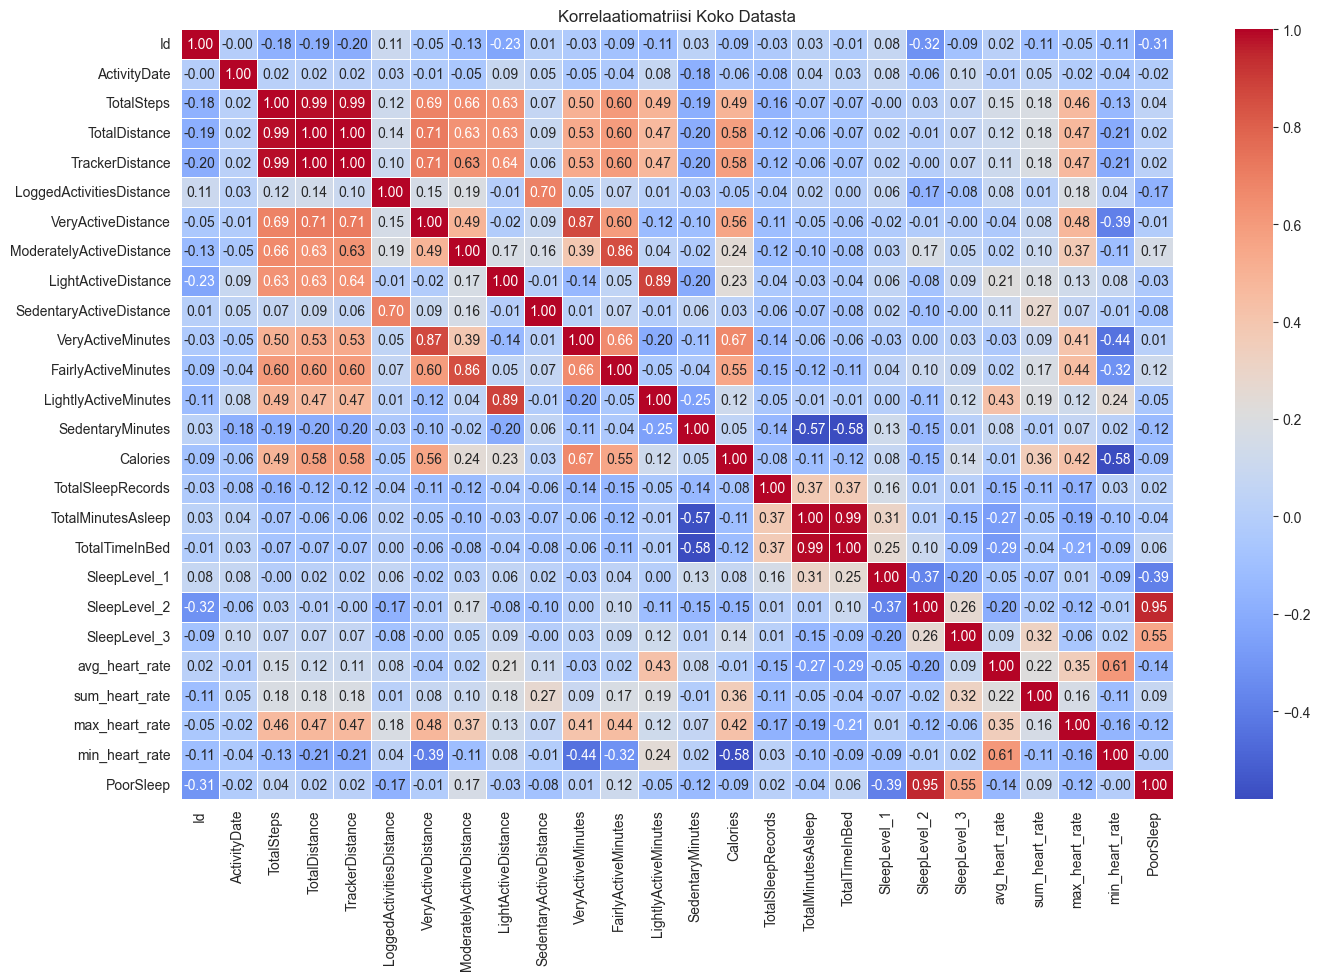

In [137]:
correlation_matrix = dailyData.corr()

# Tulosta korrelaatiomatriisi
print(correlation_matrix)

# Visualisoi korrelaatiomatriisi lämpökarttana
plt.figure(figsize=(16, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

# Lisää otsikko
plt.title('Korrelaatiomatriisi Koko Datasta')

# Näytä lämpökartta
plt.show()

### Korrelaatiomatriisi näyttää, miten eri muuttujat liittyvät toisiinsa. Korrelaatiokertoimen arvo voi vaihdella välillä -1 ja 1. 
Keskeiset löydökset:
Vahvin positiivinen yhteys:

AverageHeartRate vs. TotalSteps = 0.624
Kohtalainen positiivinen korrelaatio, eli enemmän askeleita liittyy korkeampaan keskisykeeseen.
Vahvin negatiivinen yhteys:

AverageHeartRate vs. TotalMinutesAsleep = -0.337
Kohtalainen negatiivinen korrelaatio, eli korkeampi keskisyke liittyy lyhyempään unen kestoon.
Liikunnan ja unen yhteydet ovat heikkoja:

Esimerkiksi TotalSteps vs. TotalMinutesAsleep = -0.072
Tämä viittaa siihen, että askelmäärä ei juuri vaikuta unen kestoon.

In [138]:
from scipy.stats import pearsonr

# Pearson correlation test between Heart Rate and TotalMinutesAsleep
corr_value, p_value = pearsonr(dailyData['avg_heart_rate'], dailyData['TotalMinutesAsleep'])
print(f"Pearson correlation: {corr_value}, p-value: {p_value}")

# Pearson correlation test between Heart Rate and Sleep Efficiency
corr_efficiency, p_value_efficiency = pearsonr(dailyData['avg_heart_rate'], dailyData['SleepLevel_2'])
print(f"Pearson correlation with Sleep Efficiency: {corr_efficiency}, p-value: {p_value_efficiency}")

Pearson correlation: -0.27238903174911583, p-value: 0.00020756704401779917
Pearson correlation with Sleep Efficiency: -0.19705839809842138, p-value: 0.007839495098096554


## Pearson korrelaatioanalyysi antaa tietoa siitä, miten keskisyke (avg_heart_rate) liittyy unen kestoon ja laatuun.
Keskeiset löydökset:
Vahvin negatiivinen yhteys:

Keskisyke (avg_heart_rate) vs. Unen kesto (TotalMinutesAsleep)
Pearsonin korrelaatio = -0.272
p-arvo = 0.0002
Tulkinta: On heikko negatiivinen korrelaatio, eli mitä korkeampi keskisyke, sitä lyhyempi unen kesto. Tämä yhteys on tilastollisesti merkitsevä (p < 0.05), joten tulos ei ole sattumaa.


Toinen negatiivinen yhteys:

Keskisyke (avg_heart_rate) vs. Unen tehokkuus (SleepLevel_2)
Pearsonin korrelaatio = -0.197
p-arvo = 0.0078
Tulkinta: Myös tässä on heikko negatiivinen korrelaatio, eli korkeampi keskisyke liittyy hieman heikompaan unen tehokkuuteen. Yhteys on myös tilastollisesti merkitsevä.

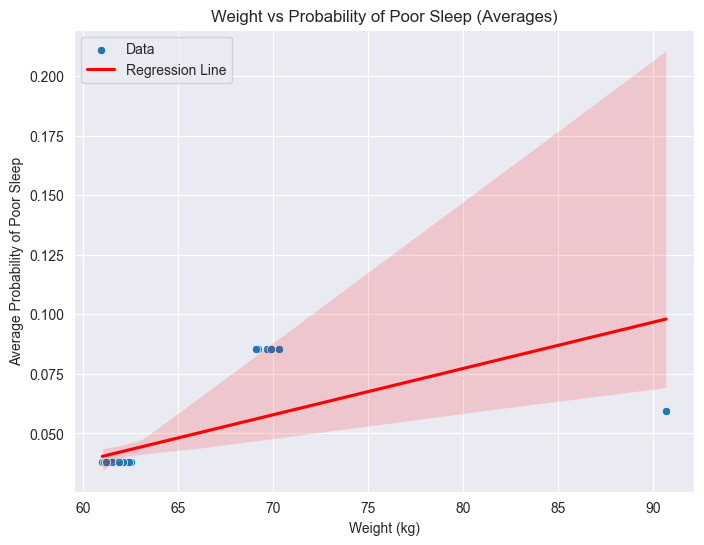

Correlation between Weight and Poor Sleep: 0.6359842910745673, p-value: 3.0657825793167674e-05


In [140]:
# Plotting the relationship between Weight and Poor Sleep
# Ensure the merged_data contains the correct weight information
merged_data['OriginalWeight'] = merged_data['WeightKg']

plt.figure(figsize=(8, 6))
sns.scatterplot(x=merged_data['OriginalWeight'], y=merged_data['AvgPoorSleep'], alpha=1, label="Data")
sns.regplot(x=merged_data['OriginalWeight'], y=merged_data['AvgPoorSleep'], scatter=False, color='red', label="Regression Line")

plt.title('Weight vs Probability of Poor Sleep (Averages)')
plt.xlabel('Weight (kg)')
plt.ylabel('Average Probability of Poor Sleep')
plt.legend()
plt.show()

# Pearson correlation between 'WeightKg' and 'AvgPoorSleep'
correlation, p_value = pearsonr(merged_data['WeightKg'], merged_data['AvgPoorSleep'])
print(f"Correlation between Weight and Poor Sleep: {correlation}, p-value: {p_value}")

### Tämä korrelaatioanalyysi antaa viitteitä siitä, miten paino (WeightKg) ja unen laatu (AvgPoorSleep) liittyvät toisiinsa.

Tulkinta ja selitys:
Painon ja huonon unen välisen korrelaation suuruus (0.636)

Positiivinen korrelaatio (0.636) tarkoittaa, että kun paino nousee, myös huonon unen määrä kasvaa. Tämä viittaa siihen, että suurempi paino voi liittyä huonompaan unenlaatuun.
Tilastollinen merkitsevyys (p-arvo ≈ 0.00003)

Pieni p-arvo (alle 0.05) tarkoittaa, että tulos ei ole sattumanvarainen, vaan painon ja unenlaadun välillä on tilastollisesti merkitsevä yhteys.

### 5. Mallin arviointi: Viides vaihe on arvioida mallia. Kuinka hyvin malli suoriutuu? Täyttääkö se liiketoiminnan vaatimukset?

### 6. Mallin käyttöönotto (Deployment)

Tässä vaiheessa keskitytään siihen, miten analyysin tulokset voidaan viedä käytäntöön ja miten mahdollinen malli voidaan ottaa käyttöön niin, että siitä on konkreettista hyötyä sekä yksilöille että yrityksille.

#### Käyttöönoton tavoitteet

Käytännön hyödyntäminen: Muuttaa analyysin löydökset konkreettisiksi suosituksiksi unen ja aktiivisuuden optimointiin.

Ennustava analytiikka: Käyttää analyysin pohjalta kehitettyjä malleja ennustamaan unen laadun muutoksia eri tekijöiden perusteella.

Käyttäjäkeskeisyys: Tarjota käyttäjäystävällisiä keinoja unen ja aktiivisuuden seurannan parantamiseksi.

Laaja soveltaminen: Mahdollistaa sekä yksilöiden että yritysten hyödyntää tietoa paremman unen ja terveyden edistämiseksi.

Käyttöönoton vaiheet

Tiedon soveltaminen käytännössä voisi olla, yksilölle unenlaadun ja terveyden parantamiseen, yhtiöille applikaatioiden avulla voisi antaa suosituksia millä tavalla oma aktiivisuus vaikuttaa uneen ja miten unta ja terveyttä voisi parantaa unenlaadulla ja urheilulla.

#### Käytännössä käyttö

Tuloksia voi analysoida miten nämä löydökset voisivat vaikuttaa eri käyttäjäryhmiin.

Kerätään palautetta käyttäjiltä tulosten hyödyllisyydestä ja mallin toimivuudesta.

Yhteenveto

Analyysin löydökset voidaan viedä käytäntöön esimerkiksi interaktiivisten raporttien, mobiilisovellusten tai hyvinvointipalveluiden muodossa. Tärkeintä on varmistaa mallin luotettavuus, tehdä tulokset helposti ymmärrettäviksi ja optimoida niitä jatkuvasti käyttäjäpalautteen perusteella.
